# List of Environmental conditions to consider

For the SFT projects, consider the following environmental parameters for your analysis.

- Wind-sea (operation and ultimate state)
- Swell-sea (operation and ultimate state)
- Wave direction: Present the wave-direction rose diagram for wind-sea and swell-sea. <br> Consider only the dominant directions for your analysis. 
- Current speed and direction (operation and ultimate state)
- Tide (esp. if using pontoons) (operation and ultimate range)
- Seismic activity (if applicable)

# Extracting data from online dataset

We present the procedure for extracting the Hs and Tz for a location from online dataset.

## 1. Download data from onilne dataset

The following steps can be taken to extract environmental data at the location: 

1. Log in with user account on the site: <br>
https://cds.climate.copernicus.eu/ <br>
Use e-mail: makeYourEmailAccount<br>
Password: Password<br>
<img width="80%" src="./img/nb01_fig001.png" />

1. Select **Datasets** and look for **ERA5 hourly data on single levels from 1940 to present**<br>
<img width="80%" src="./img/nb01_fig001f.png" />

1. Select **Download** and choose **Reanalysis** <br>
<img width="80%" src="./img/nb01_fig002.png" />

1. Here you may pick one or two variables of interest. <br>
It is noted that more detailed ocean waves data can be found under a separate tab. <br>
<img width="80%" src="./img/nb01_fig002b_2.png" /><br>
We are interested in 

- **Significant height of wind waves**.
- **Significant height of total swell**
- **Peak wave period**
- **Significant height of combined wind waves and swell waves**


1. Choose one or several years. <br> 
For the statistical review it is important to have a number of years but the data which can be extracted is limited. <br> 
The choice here is to extract the years **2018**, **2019**, **2020** and **2021**. Next to this all year is chosen **January** etc. as well as all days.  <br>
<img width="80%" src="./img/nb01_fig003.png" /> 

1. For the time three hour values are chosen (to reduce the amount of data).  <br>
<img width="80%" src="./img/nb01_fig004.png" /> 

1. For Geographical area choose **Sub-region**. The longitude & latitude limits are given at the western and eastern side as well as Northern and Southern side. Data is extracted in the area between the values. <br>
<img width="80%" src="./img/nb01_fig005.png" /> 

1. On the format choose **NetCFD** <br>
<img width="80%" src="./img/nb01_fig006.png" /> 

1. If all has been filled in correctly data can be extracted. **Submit Form** <br>
<img width="80%" src="./img/nb01_fig007.png" /> 

1. The request is now shown in a new page and by expanding the product details are shown. This request took around 8 min to deliver. <br>
<img width="80%" src="./img/nb01_fig008.png" /> 

1. The data can be downloaded. Once this is done the Python script can be used to extract the data.  <br>
<img width="80%" src="./img/nb01_fig009.png" /> 


## 2. Extract data from dataset

This is achieved using **netCDF4** package

In [21]:
# pip install netCDF4

In [22]:
from netCDF4 import Dataset
nc = Dataset('data/merged_wave_data.nc', 'r')
print(nc.variables)
pass

{'number': <class 'netCDF4.Variable'>
int64 number()
    long_name: ensemble member numerical id
    units: 1
    standard_name: realization
unlimited dimensions: 
current shape = ()
filling on, default _FillValue of -9223372036854775806 used, 'valid_time': <class 'netCDF4.Variable'>
int64 valid_time(valid_time)
    long_name: time
    standard_name: time
    units: seconds since 1970-01-01
    calendar: proleptic_gregorian
unlimited dimensions: 
current shape = (15099,)
filling on, default _FillValue of -9223372036854775806 used, 'latitude': <class 'netCDF4.Variable'>
float64 latitude(latitude)
    _FillValue: nan
    units: degrees_north
    standard_name: latitude
    long_name: latitude
    stored_direction: decreasing
unlimited dimensions: 
current shape = (3,)
filling on, 'longitude': <class 'netCDF4.Variable'>
float64 longitude(longitude)
    _FillValue: nan
    units: degrees_east
    standard_name: longitude
    long_name: longitude
unlimited dimensions: 
current shape = (5,)


In [23]:
lon = nc.variables['longitude']
lat = nc.variables['latitude']
time = nc.variables['valid_time']

for d in nc.dimensions.items():
    print(d)

('valid_time', "<class 'netCDF4.Dimension'>": name = 'valid_time', size = 15099)
('latitude', "<class 'netCDF4.Dimension'>": name = 'latitude', size = 3)
('longitude', "<class 'netCDF4.Dimension'>": name = 'longitude', size = 5)


#### The dataset contains values at 2 locations for 17536 time-instances

In [24]:
lon_array = lon[:]
lat_array = lat[:]
Time_array = time[:]

print(lon_array)

print(lat_array)

print(Time_array)
pass

[104.5 105.  105.5 106.  106.5]
[-5.5 -6.  -6.5]
[1451606400 1451628000 1451649600 ... 1777680000 1777701600 1777723200]


#### Extracting significant wave-height (hs) or Peak period(tp)

<img width="80%" src="./img/var_2.png" /><br>
<img width="80%" src="./img/var_1.png" /><br>
<img width="80%" src="./img/var_3.png" /><br>
<img width="80%" src="./img/var_4.png" /><br>

In [25]:
hs = nc.variables['swh']
tp = nc.variables['pp1d']

hs_array = hs[:]
period_array = tp[:]

print("Hs array")
print(hs_array)

print("Tp array")
print(period_array)

Hs array
[[[-- -- -- 0.31472599506378174 0.42288029193878174]
  [1.3498822450637817 1.1242963075637817 0.6653119325637817 -- --]
  [1.4573041200637817 1.2961713075637817 0.6340619325637817 -- --]]

 [[-- -- -- 0.29321157932281494 0.39282095432281494]
  [1.321287751197815 1.099852204322815 0.6591783761978149 -- --]
  [1.425779938697815 1.269774079322815 0.6301256418228149 -- --]]

 [[-- -- -- 0.2833908796310425 0.3551682233810425]
  [1.2943772077560425 1.0975998640060425 0.6505783796310425 -- --]
  [1.3976486921310425 1.2516525983810425 0.6222580671310425 -- --]]

 ...

 [[-- -- -- 0.2354915738105774 0.1900814175605774]
  [1.6212337017059326 1.3355891704559326 0.6720150113105774 -- --]
  [1.8341243267059326 1.5965754985809326 0.7066829800605774 -- --]]

 [[-- -- -- 0.25342434644699097 0.22803372144699097]
  [1.5278384685516357 1.2463443279266357 0.632574737071991 -- --]
  [1.7226626873016357 1.4675357341766357 0.653570830821991 -- --]]

 [[-- -- -- 0.24237477779388428 0.2113689184188842

In [26]:
i = 1 #for the present case, the values can be 0,1
j = 1 #for the present case, the values can be 0,1
hs_array = hs[:,i,j]
period_array = tp[:,i,j]

print("Hs array")
print(hs_array)

print("Tp array")
print(period_array)

Hs array
[1.1242963 1.0998522 1.0975999 ... 1.3355892 1.2463443 1.1632732]
Tp array
[12.879738  12.461769  12.2801285 ... 12.860695  12.537941  12.3582535]


#### Exporting to excel sheet

In [27]:
import pandas as pd
import numpy as np


data = np.array([Time_array,
         hs_array,
         period_array])
data = data.T


df = pd.DataFrame(data, columns=['time', 'Hs', 'Tp'])

df.to_csv('hsarrays.csv', index=False)

## 3. Visualisation of the data

In [28]:
# pip install seaborn

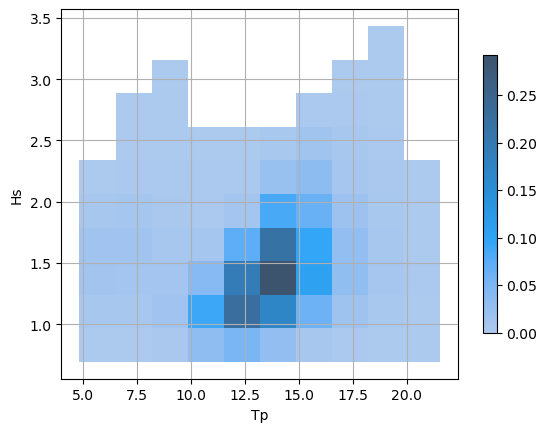

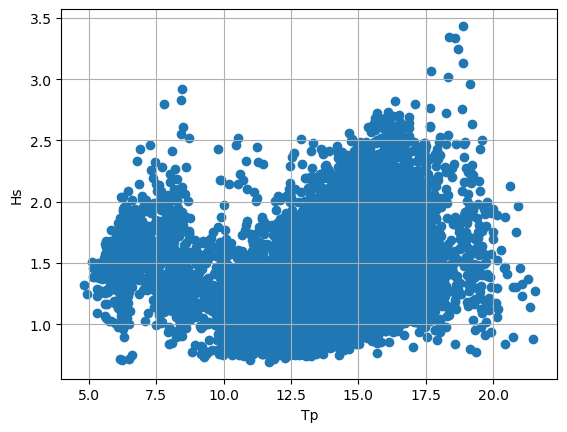

In [29]:
import seaborn as sns
import pandas as pd
import matplotlib.pylab as plt

dataIn = pd.read_csv('hsarrays.csv')

sns.histplot(data=dataIn, x = 'Tp', y = 'Hs', bins=10, cbar=True, cbar_kws=dict(shrink=.75), stat='density');
plt.grid()

plt.figure()
plt.scatter(dataIn['Tp'], dataIn['Hs'])
plt.xlabel('Tp')
plt.ylabel('Hs')
plt.grid()